In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)


In [2]:
import os, shutil

os.makedirs("data", exist_ok=True)

for fname in ["churn-bigml-80.csv", "churn-bigml-20.csv"]:
    if os.path.exists(fname):
        shutil.move(fname, f"data/{fname}")
    elif os.path.exists(f"sample_data/{fname}"):
        shutil.move(f"sample_data/{fname}", f"data/{fname}")

print(os.listdir("data"))

['churn-bigml-20.csv', 'churn-bigml-80.csv']


In [3]:
def load_and_prep(path):
    df = pd.read_csv(path)
    df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
    df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})
    df["Churn"] = df["Churn"].astype(int)
    df = df.drop(columns=["State", "Area code"])
    return df

train_df = load_and_prep("data/churn-bigml-80.csv")
test_df = load_and_prep("data/churn-bigml-20.csv")

X_train, y_train = train_df.drop(columns=["Churn"]), train_df["Churn"]
X_test, y_test = test_df.drop(columns=["Churn"]), test_df["Churn"]
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (2666, 17) Test: (667, 17)


In [4]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 3],
}

rf = RandomForestClassifier(random_state=42, class_weight="balanced")
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_.round(4))

best_rf = grid_search.best_estimator_


Best parameters: {'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV F1-score: 0.8222


In [5]:
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="f1")
print("5-fold CV F1 scores:", cv_scores.round(4))
print("Mean CV F1:", cv_scores.mean().round(4))


5-fold CV F1 scores: [0.8322 0.7826 0.8627 0.7945 0.8392]
Mean CV F1: 0.8222


In [6]:
y_pred = best_rf.predict(X_test)

print(f"Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Test Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"Test F1-score:  {f1_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))


Test Accuracy:  0.9625
Test Precision: 0.9070
Test Recall:    0.8211
Test F1-score:  0.8619

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       572
           1       0.91      0.82      0.86        95

    accuracy                           0.96       667
   macro avg       0.94      0.90      0.92       667
weighted avg       0.96      0.96      0.96       667



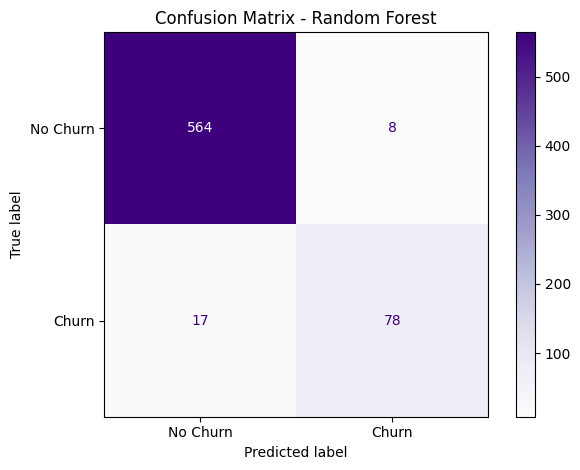

In [7]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(cmap="Purples")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()


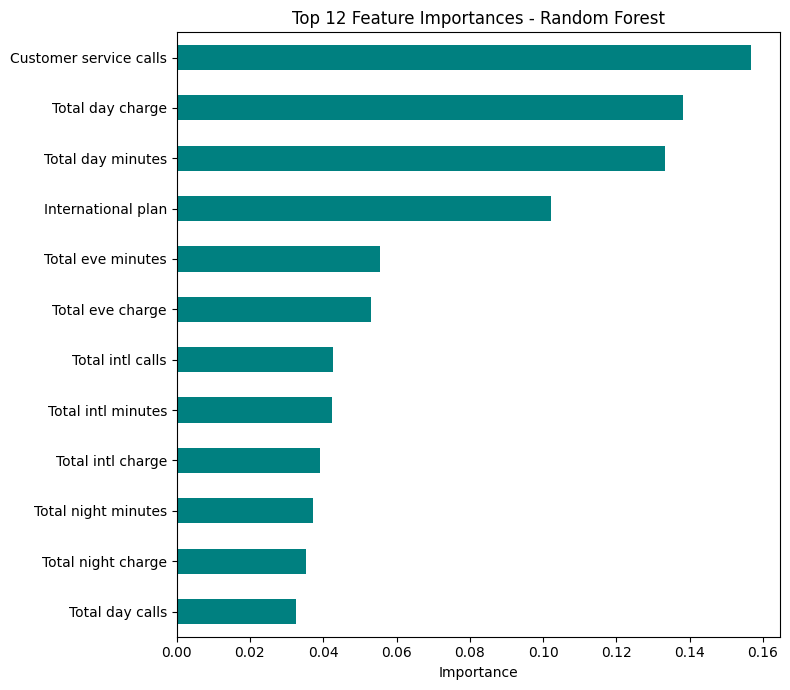

,0
Customer service calls,0.156784
Total day charge,0.138030
Total day minutes,0.133305
International plan,0.102147
Total eve minutes,0.055617
Total eve charge,0.053126
Total intl calls,0.042609
Total intl minutes,0.042312
Total intl charge,0.039071
Total night minutes,0.037259


In [8]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
importances.head(12).sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 12 Feature Importances - Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)
